# **Meshlands - Clouds**
In the Meshlands configurations, clouds play a major role in shaping and regulating the climate. This notebook presents the main plots used to determine the precise role of clouds in the climate response. \
The sections are organized as:
- Cloud Repartition
- Cloud Forcing
- Comparison

## **Initial Set Up-related**

### Imports

In [1]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob

########## Cartopy ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## SciPy ##########
import scipy.ndimage as ndi

########## Xarray ##########
import xarray as xr

### Function Definitions

In [2]:
def get_mapdata(ds, row):
    '''
    Calculates a mapdata depending on the row of the plot, specifically for the comparison plot.
    '''
    if row == 0:
        return ds['CLDHGH'].mean('year') - ds['CLDLOW'].mean('year')
    elif row == 1:
        return ds['SWCF'].mean('year') + ds['LWCF'].mean('year')

### Path Definitions

In [3]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [4]:
# Creates a list of atmospheric variables
atm_vars = ['CLDHGH','CLDLOW','CLDMED','CLDTOT','SWCF','LWCF','CLOUD','U','V']

### Dictionary Definitions

In [5]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [6]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


# **Cloud Repartition**
The localization of clouds in the atmosphere is directly correlated to their ability to reflect or absorb radiation. Low-level clouds reflect solar rays while high-level clouds absorb longwave radiation, causing a greenhouse effect. This part is dedicated to the study of the cloud repartition with respect to their position in the atmosphere.

## **Vertical Repartition**

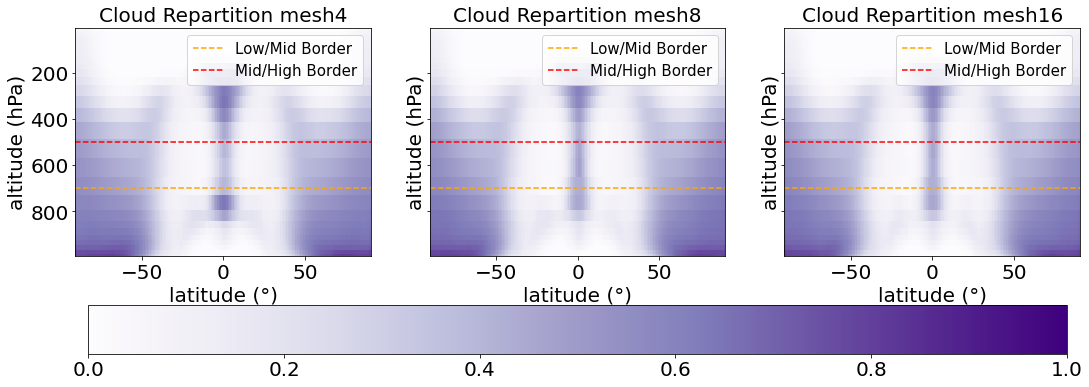

In [7]:
# Creates a list containing all the data needed for the plotting
plot_data = []
for case in config :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    cld = ds_case['CLOUD'].mean('year').mean('lon')
    
    # Fill the list with a 2-tuple containing the case and the mapdata 
    plot_data.append((case,cld))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, cld) in zip(axes, plot_data):
    lat = cld['lat']
    lev = cld['lev']
    
    # draw the colormesh
    im = ax.pcolormesh(lat, lev, cld, cmap='Purples', vmin=0, vmax=1, shading='auto')
    
    ax.set_title(f'Cloud Repartition {case}',fontsize=20)
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=20)
    ax.set_ylim(lev.max().values, lev.min().values)

    # draw the border between each cloud types
    ax.axhline(y=700, color='orange', linestyle='--', linewidth=1.5, label='Low/Mid Border')
    ax.axhline(y=500, color='red', linestyle='--', linewidth=1.5, label='Mid/High Border')
    ax.legend(fontsize=15)

cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.ax.tick_params(labelsize=20)

plt.show()
plt.close()

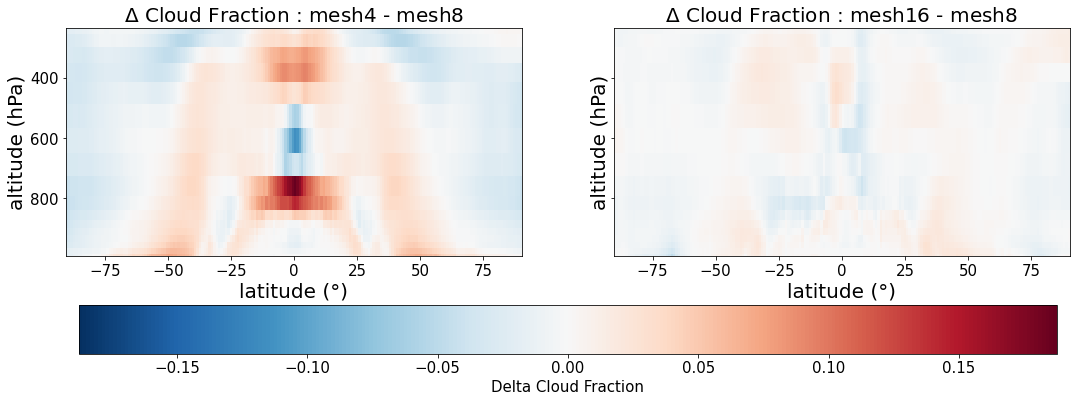

In [8]:
# Collects the datas needed for the reference configuration
ds8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = ds8['CLOUD'].mean('year').mean('lon')

# Calculates the difference between the current case and the reference
plot_data = []
for case in ['mesh4','mesh16'] :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    T = ds_case['CLOUD'].mean('year').mean('lon') - ref

    # Fill the list with a 2-tuple containing the case and the mapdata
    plot_data.append((case,T))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all Q for the colorbar
vmin = min(float(T.min().values) for (case, T) in plot_data)
vmax = max(float(T.max().values) for (case, T) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, (case, T) in zip(axes, plot_data):
    lat = T['lat']
    # Limits the altitude dimension to keep only the troposphere (more than 250 hPa)
    lev = T['lev'][15:]
    
    # draw the colormap
    im = ax.pcolormesh(lat, lev, T[15:,:], cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    
    ax.set_title(f'$\Delta$ Cloud Fraction : {case} - mesh8', fontsize=20)
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    ax.set_ylim(lev.max().values, lev.min().values)

cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('Delta Cloud Fraction',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

## **Total Cloud Fraction**

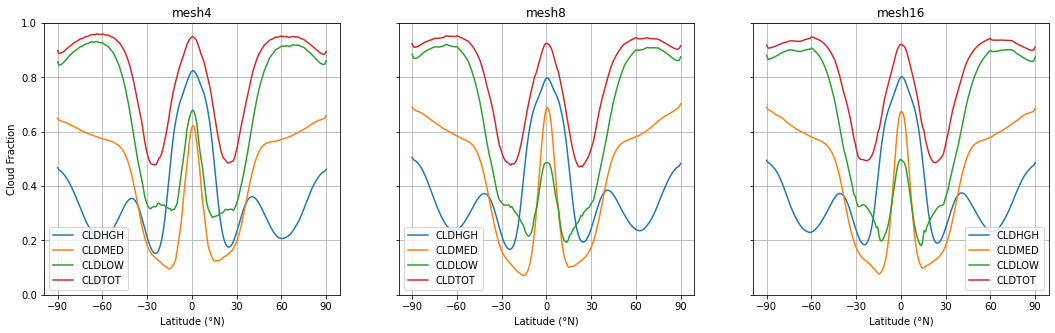

In [9]:
# Overall: creates a plot for each patch size to compare zonally averaged cloud fraction

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for (i,case) in enumerate(config) :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    
    mapdata = ds_case['CLDHGH'].mean('year').mean('lon')
    axes[i].plot(mapdata.lat,mapdata,label='CLDHGH')

    mapdata = ds_case['CLDMED'].mean('year').mean('lon')
    axes[i].plot(mapdata.lat,mapdata,label='CLDMED')

    mapdata = ds_case['CLDLOW'].mean('year').mean('lon')
    axes[i].plot(mapdata.lat,mapdata,label='CLDLOW')

    mapdata = ds_case['CLDTOT'].mean('year').mean('lon')
    axes[i].plot(mapdata.lat,mapdata,label='CLDTOT')

    axes[i].set_title(case)
    axes[i].set_xlabel('Latitude (°N)')
    axes[i].set_xticks([-90,-60,-30,0,30,60,90])
    axes[i].set_ylim([0,1])
    axes[i].legend()
    axes[i].grid()

axes[0].set_ylabel('Cloud Fraction')

plt.show()
plt.close()

## **Low Level Cloud Fraction**

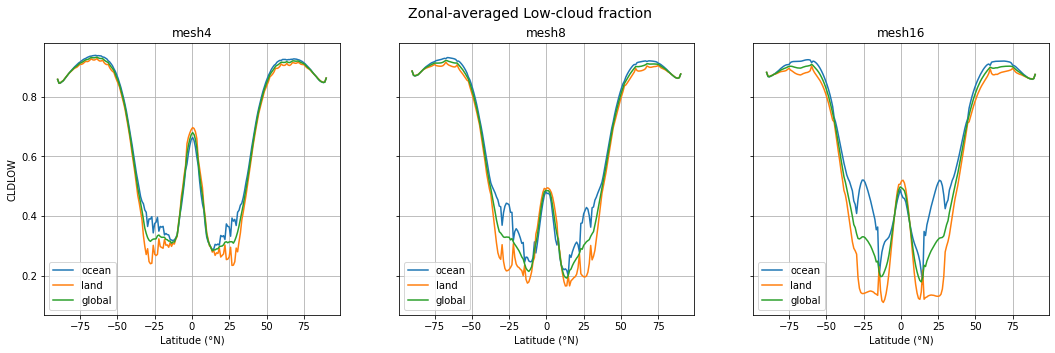

In [10]:
# Overall: creates a plot for each patch size to show the zonally averaged low-level cloud cover

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['CLDLOW'].mean('year')

    # Collects the mask to separate land and ocean average
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case)
    axes[i].set_xlabel('Latitude (°N)')
    axes[i].legend()
    axes[i].grid()

axes[0].set_ylabel('CLDLOW')

plt.suptitle('Zonal-averaged Low-cloud fraction', fontsize=14)

plt.show()
plt.close()

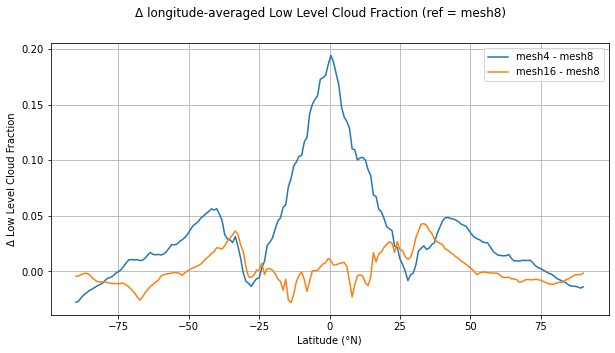

In [11]:
plt.figure(figsize=(10,5))

# Groups the case's atmospheric time series dictionary by year, calculates the mean
ds_mesh4 = ts_dict_atm['mesh4'].groupby('time.year').mean('time').mean('lon')
ds_mesh8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time').mean('lon')
ds_mesh16 = ts_dict_atm['mesh16'].groupby('time.year').mean('time').mean('lon')

# Finds the difference between the case's data and the mesh4's data
mapdata4 = (ds_mesh4['CLDLOW'].mean('year')) - (ds_mesh8['CLDLOW'].mean('year'))
mapdata16 = (ds_mesh16['CLDLOW'].mean('year')) - (ds_mesh8['CLDLOW'].mean('year'))

# Draws the plots
plt.plot(mapdata4.lat,mapdata4,label='mesh4 - mesh8')
plt.plot(mapdata16.lat,mapdata16,label='mesh16 - mesh8')

# Set's the figure's title
plt.suptitle('Δ longitude-averaged Low Level Cloud Fraction (ref = mesh8)')

plt.xlabel('Latitude (°N)')
plt.ylabel('Δ Low Level Cloud Fraction')
plt.legend()
plt.grid()

plt.show()
plt.close()

## **Mid-Level Cloud Fraction**

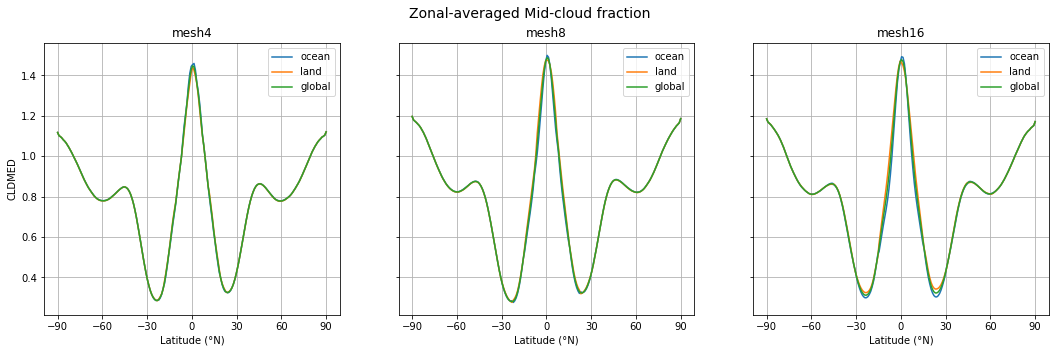

In [12]:
# Overall: creates a plot for each patch size to show the zonally averaged mid-level cloud cover

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['CLDHGH'].mean('year') + ds_case['CLDMED'].mean('year')

    # Collects the mask to separate ocean and land average
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    # Plots the different mapdata computed (ocean mean, land mean, and global mean)
    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case)
    axes[i].set_xlabel('Latitude (°N)')
    axes[i].set_xticks([-90,-60,-30,0,30,60,90])
    axes[i].legend()
    axes[i].grid()

axes[0].set_ylabel('CLDMED')

plt.suptitle('Zonal-averaged Mid-cloud fraction', fontsize=14)

plt.show()
plt.close()

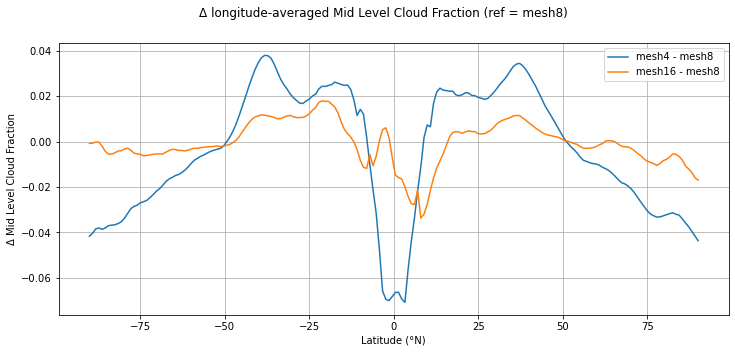

In [13]:
# Sets the figure's size
fig = plt.figure(figsize=(12, 5))

# Set's the figure's title
fig.suptitle('Δ longitude-averaged Mid Level Cloud Fraction (ref = mesh8)')

# Groups the case's atmospheric time series dictionary by year, calculates the mean
ds_mesh4 = ts_dict_atm['mesh4'].groupby('time.year').mean('time').mean('lon')
ds_mesh8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time').mean('lon')
ds_mesh16 = ts_dict_atm['mesh16'].groupby('time.year').mean('time').mean('lon')

# Finds the difference between the case's data and the mesh4's data
mapdata4 = (ds_mesh4['CLDMED'].mean('year')) - (ds_mesh8['CLDMED'].mean('year'))
mapdata16 = (ds_mesh16['CLDMED'].mean('year')) - (ds_mesh8['CLDMED'].mean('year'))

# Draws the plots
plt.plot(mapdata4.lat,mapdata4,label='mesh4 - mesh8')
plt.plot(mapdata16.lat,mapdata16,label='mesh16 - mesh8')
plt.xlabel('Latitude (°N)')
plt.ylabel('Δ Mid Level Cloud Fraction')
plt.legend()
plt.grid()

plt.show()
plt.close()

## **High-Level Cloud Fraction**

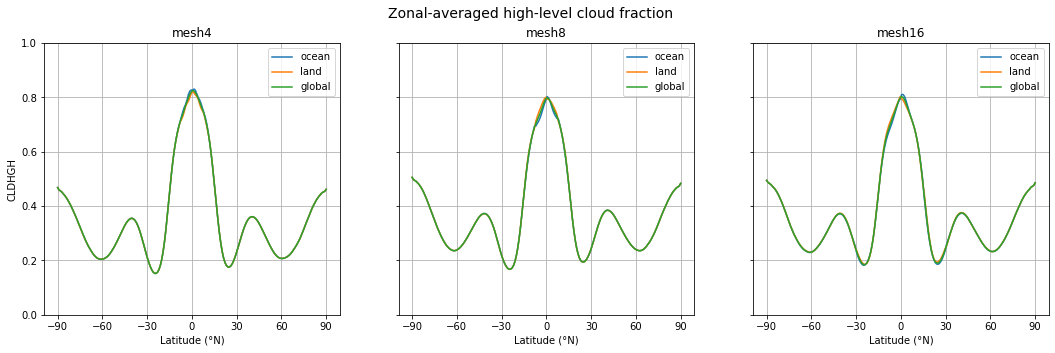

In [14]:
# Overall: creates a plot for each patch size to show the zonally averaged high-level cloud cover

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['CLDHGH'].mean('year')

    # Collects the mask to separate the land and ocean average
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    # Plots separately the different averages computed
    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case)
    axes[i].set_xlabel('Latitude (°N)')
    axes[i].set_xticks([-90,-60,-30,0,30,60,90])
    axes[i].set_yticks([0,0.2,0.4,0.6,0.8,1])
    axes[i].legend()
    axes[i].grid()

axes[0].set_ylabel('CLDHGH')

plt.suptitle('Zonal-averaged high-level cloud fraction', fontsize=14)

plt.show()
plt.close()

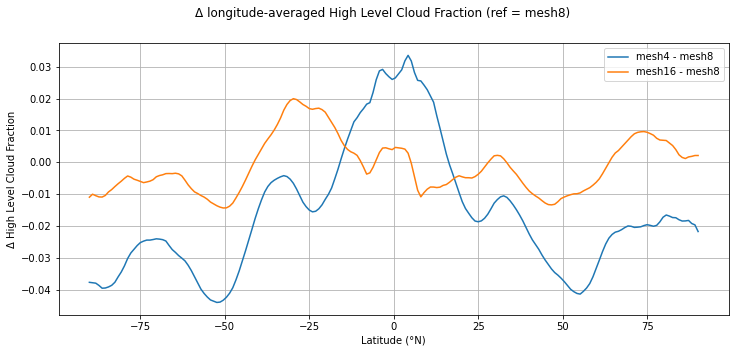

In [15]:
# Sets the figure's size
fig = plt.figure(figsize=(12, 5))

# Set's the figure's title
fig.suptitle('Δ longitude-averaged High Level Cloud Fraction (ref = mesh8)')

# Groups the case's atmospheric time series dictionary by year, calculates the mean
ds_mesh4 = ts_dict_atm['mesh4'].groupby('time.year').mean('time').mean('lon')
ds_mesh8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time').mean('lon')
ds_mesh16 = ts_dict_atm['mesh16'].groupby('time.year').mean('time').mean('lon')

# Finds the difference between the case's data and the mesh4's data
mapdata4 = (ds_mesh4['CLDHGH'].mean('year')) - (ds_mesh8['CLDHGH'].mean('year'))
mapdata16 = (ds_mesh16['CLDHGH'].mean('year')) - (ds_mesh8['CLDHGH'].mean('year'))

# Draws the plots
plt.plot(mapdata4.lat,mapdata4,label='mesh4 - mesh8')
plt.plot(mapdata16.lat,mapdata16,label='mesh16 - mesh8')
plt.xlabel('Latitude (°N)')
plt.ylabel('Δ High Level Cloud Fraction')
plt.legend()
plt.grid()

plt.show()
plt.close()

# **Cloud Forcing**
The most important aspect when studying the role of clouds in the climate is their radiative feedback. The following sections provide plots that show the total cloud forcing induced in all experiments. The plots that are shown represent the sum of the shortwave and the longwave forcing.

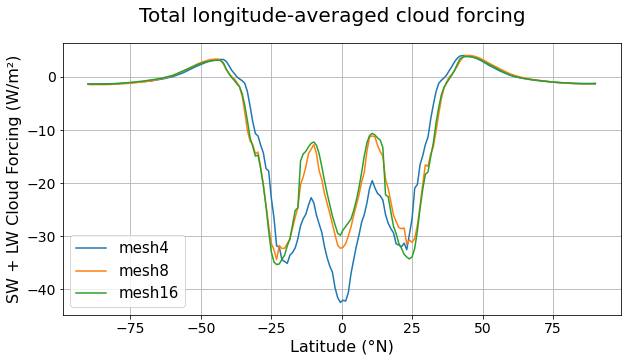

In [16]:
# Overall: compares the zonally averaged total cloud forcing (shortwave + longwave) for all meshes

plt.figure(figsize=(10,5))
plt.suptitle('Total longitude-averaged cloud forcing',fontsize=20)

for case in config :

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the value of humidity integrated vertically (altitude)
    mapdata = ds_case['SWCF'].mean('year').mean('lon') + ds_case['LWCF'].mean('year').mean('lon')
    
    plt.plot(mapdata.lat,mapdata,label=f'{case}')

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('SW + LW Cloud Forcing (W/m²)',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)

plt.show()
plt.close()

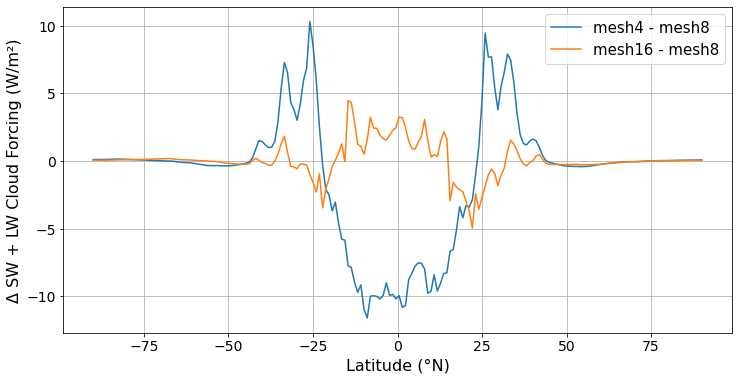

In [17]:
plt.figure(figsize=(12,6))

# Calculates the reference case for the comparison
ds_8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = ds_8['SWCF'].mean('year').mean('lon') + ds_8['LWCF'].mean('year').mean('lon')

for case in ['mesh4','mesh16'] :
    
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates and plots the difference between the current case and the reference case
    mapdata = ds_case['SWCF'].mean('year').mean('lon') + ds_case['LWCF'].mean('year').mean('lon') - ref
    plt.plot(mapdata.lat,mapdata,label=f'{case} - mesh8')

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('Δ SW + LW Cloud Forcing (W/m²)',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)

plt.show()
plt.close()

# **Cloud Repartition and Cloud Forcing Comparison**
This last section provides a comparison between the greenhouse effect and the albedo effect of clouds. Indeed, plots show the differences in high-level and low-level clouds and the total cloud forcing (sum of shortwave and longwave effects). The first plot shows global results, and the second one provides a focus on the Tropics.

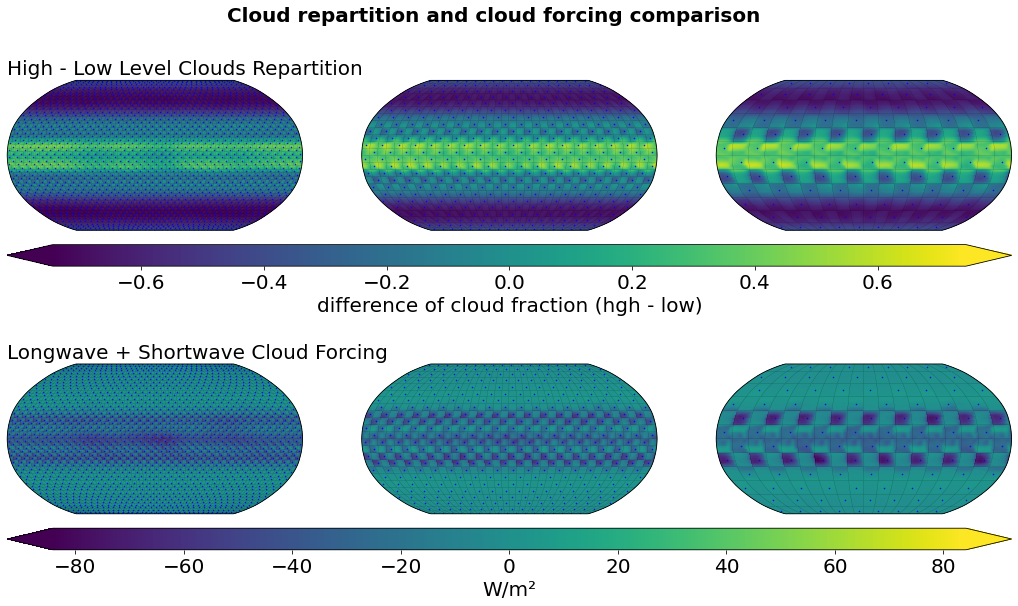

In [18]:
# Overall: compares the high-level and low-level cloud differences with the total cloud forcing

fig = plt.figure(figsize=(18, 10))

# Generates the plot structure (alternating pattern between plots row and colorbars)
gs = fig.add_gridspec(4, 3, width_ratios=[1, 1, 1], height_ratios=[1, 0.2, 1, 0.2])
ax_map_list = [[fig.add_subplot(gs[2*i, j], projection=ccrs.Robinson()) for j in range(3)] for i in range(2)]
cs_list = [None, None]

fig.suptitle('Cloud repartition and cloud forcing comparison', fontsize=20, fontweight='bold', y=0.95)
row_titles = ['High - Low Level Clouds Repartition',
              'Longwave + Shortwave Cloud Forcing']
row_units = ['difference of cloud fraction (hgh - low)',
             'W/m²']

# Calculates max and min values to generate a common and unique colorbar for each row of plots
vmin_list, vmax_list = [], []
for row in range(2):
    all_vals = []
    for case in ['mesh4','mesh8','mesh16']:
        ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
        mapdata = get_mapdata(ds_case,row)
        all_vals.append(float(mapdata.min()))
        all_vals.append(float(mapdata.max()))
    vmax = max(abs(min(all_vals)), abs(max(all_vals)))
    vmin_list.append(-vmax)
    vmax_list.append(vmax)

# Sets the row's title
for row in range(2):
    ax_map_list[row][0].set_title(row_titles[row], fontsize=20, loc='left', pad=6)

for (i, case) in enumerate(['mesh4','mesh8','mesh16']):
    
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the ocean mask to differentiate oceans from lands (serves later to scatter blue dots)
    ocean_mask = (mesh_dict[case]['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    dlon = mesh_dict[case]['xc'][0, 1] - mesh_dict[case]['xc'][0, 0]
    dlat = mesh_dict[case]['yc'][1, 0] - mesh_dict[case]['yc'][0, 0]
    lon_centers, lat_centers = [], []
    for label in range(1, num_features + 1):
        y_cm, x_cm = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        lon_centers.append(mesh_dict[case]['xc'][0, 0] + x_cm * dlon)
        lat_centers.append(mesh_dict[case]['yc'][0, 0] + y_cm * dlat)

    # Collects coordinates to plot the coastlines
    xc_cyc   = np.concatenate([mesh_dict[case]["xc"],   mesh_dict[case]["xc"][:, :1] + 360], axis=1)
    yc_cyc   = np.concatenate([mesh_dict[case]["yc"],   mesh_dict[case]["yc"][:, :1]],        axis=1)
    mask_cyc = np.concatenate([mesh_dict[case]["mask"], mesh_dict[case]["mask"][:, :1]],       axis=1)

    for row in range(2):
        # Calculates the final mapdata
        mapdata = get_mapdata(ds_case,row)
        # Sets the figure where the mapdata is plotted 
        ax = ax_map_list[row][i]

        # Plots the coastlines for the entire planet
        ax.contour(xc_cyc, yc_cyc, mask_cyc, levels=[0.5], colors="black", linewidths=0.1, transform=ccrs.PlateCarree())
        ax.set_global()

        # Creates a cyclic point to ensure longitude plots smoothly 
        cyclic_data, cyclic_lons = add_cyclic_point(mapdata, coord=mapdata.lon)
        # Draws the colormesh
        cs = ax.pcolormesh(cyclic_lons, mapdata.lat, cyclic_data, cmap='viridis', vmin=vmin_list[row], vmax=vmax_list[row], transform=ccrs.PlateCarree())
        # Adds the colormesh to a list used later to draw the colorbars
        cs_list[row] = cs

        # Draws blue dots to identify ocean cells
        ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=1, transform=ccrs.PlateCarree())

# Manages the positioning and display of colorbars
fig.canvas.draw()
for row in range(2):
    ax_ref  = ax_map_list[row][0]
    ax_last = ax_map_list[row][-1]
    pos0 = ax_ref.get_position()
    pos1 = ax_last.get_position()
    cax = fig.add_axes([pos0.x0, pos0.y0 - 0.05, pos1.x1 - pos0.x0, 0.03])
    cb = fig.colorbar(cs_list[row], cax=cax, orientation='horizontal', extend='both')
    cb.set_label(row_units[row], fontsize=20)
    cb.ax.tick_params(labelsize=20)

plt.show()
plt.close()

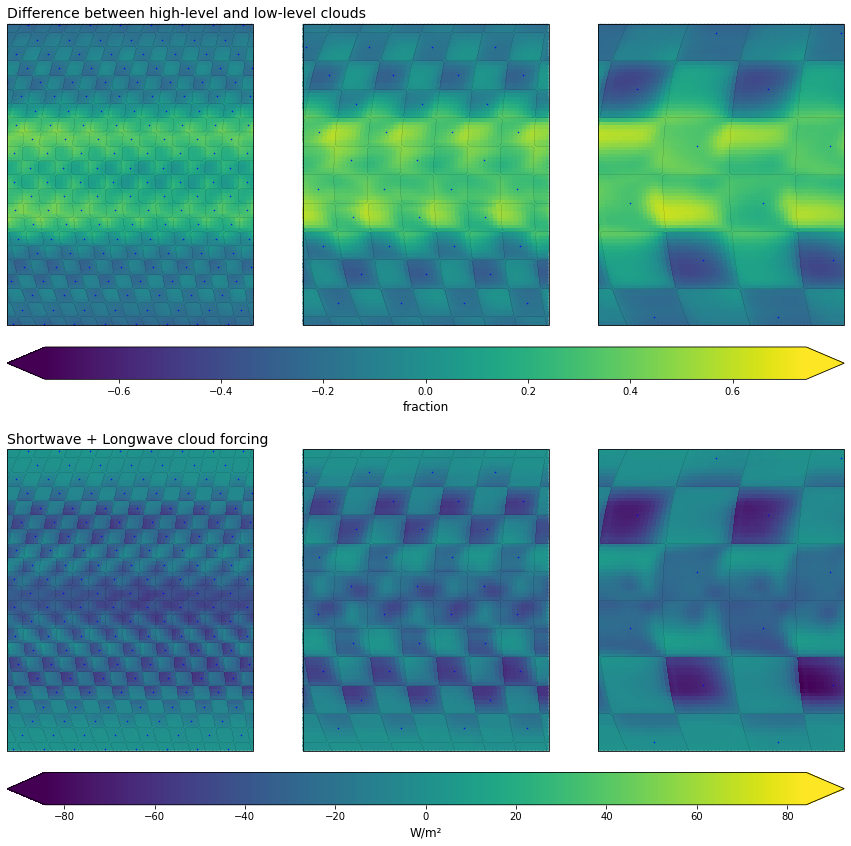

In [19]:
# Overall: compares the high-level and low-level cloud differences with the total cloud forcing, focusing on the Subtropics

fig = plt.figure(figsize=(15, 15))

# Generates the plot's structure (alternating pattern between plots row and colorbars)
gs = fig.add_gridspec(4, 3, width_ratios=[1, 1, 1], height_ratios=[1, 0.1, 1, 0.1])
ax_map_list = [[fig.add_subplot(gs[2*i, j], projection=ccrs.Robinson()) for j in range(3)] for i in range(2)]
cs_list = [None, None]

row_titles = ['Difference between high-level and low-level clouds',
              'Shortwave + Longwave cloud forcing']

row_units = ['fraction',
             'W/m²']

# Calculates max and min values to generate a common and unique colorbar for each plot's row
vmin_list, vmax_list = [], []
for row in range(2):
    all_vals = []
    for case in ['mesh4','mesh8','mesh16']:
        ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
        mapdata = get_mapdata(ds_case,row)
        all_vals.append(float(mapdata.min()))
        all_vals.append(float(mapdata.max()))
    vmax = max(abs(min(all_vals)), abs(max(all_vals)))
    vmin_list.append(-vmax)
    vmax_list.append(vmax)

# Sets the row's title
for row in range(2):
    ax_map_list[row][0].set_title(row_titles[row], fontsize=14, loc='left', pad=6)
    
for (i, case) in enumerate(['mesh4','mesh8','mesh16']):
    
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    
    # Calculates the ocean mask to differentiate oceans from lands (serves later to scatter blue dots)
    ocean_mask = (mesh_dict[case]['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers, lat_centers = [], []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        dlon = mesh_dict[case]['xc'][0, 1] - mesh_dict[case]['xc'][0, 0]
        dlat = mesh_dict[case]['yc'][1, 0] - mesh_dict[case]['yc'][0, 0]
        lon_centers.append(mesh_dict[case]['xc'][0, 0] + x * dlon)
        lat_centers.append(mesh_dict[case]['yc'][0, 0] + y * dlat)

    # Collects coordinates to plot the coastlines of this specific case
    xc_cyc   = np.concatenate([mesh_dict[case]["xc"],   mesh_dict[case]["xc"][:, :1] + 360], axis=1)
    yc_cyc   = np.concatenate([mesh_dict[case]["yc"],   mesh_dict[case]["yc"][:, :1]],        axis=1)
    mask_cyc = np.concatenate([mesh_dict[case]["mask"], mesh_dict[case]["mask"][:, :1]],       axis=1)

    for row in range(2):
        # Calculates the final mapdata
        mapdata = get_mapdata(ds_case, row)
        # Sets the figure where the mapdata is plotted 
        ax = ax_map_list[row][i]

        # Plots the coastlines
        ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
        # Sets the view to be focused on Tropics
        ax.set_extent([-120, -50, -40, 40], crs=ccrs.PlateCarree())

        # Creates a cyclic point to ensure longitude plots smoothly 
        cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=mapdata.lon)

        # Plots the data as a coloured mesh with different colorbars because of different units
        cs = ax.pcolormesh(cyclic_lons, mapdata.lat, cyclic_data, cmap='viridis', vmin=vmin_list[row], vmax=vmax_list[row], transform=ccrs.PlateCarree())
        # Adds the colormesh to a list used later to draw the colorbars
        cs_list[row] = cs

        # Draws blue dots to identify ocean cells
        ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=1, transform=ccrs.PlateCarree())

# Manages positioning and display of colorbars
fig.canvas.draw()
for row in range(2):
    ax_ref  = ax_map_list[row][0]
    ax_last = ax_map_list[row][-1]
    pos0 = ax_ref.get_position()
    pos1 = ax_last.get_position()
    cax = fig.add_axes([pos0.x0, pos0.y0 - 0.05, pos1.x1 - pos0.x0, 0.03])
    cb = fig.colorbar(cs_list[row], cax=cax, orientation='horizontal', extend='both')
    cb.set_label(row_units[row], fontsize=12)
    cb.ax.tick_params(labelsize=10)
    
plt.show()
plt.close()